# Measure Transport, Chained `TrueMeasure` Transformations, and Importance Sampling in QMCPy

## Mathematical design before implementation

### Research question

> Can QMCPy generalize its existing recursive `TrueMeasure` composition so that transformations can be chained across compatible non-unit-cube spaces, while correctly tracking Jacobians, target weights, proposal densities, and normalized or unnormalized measures?

### Why this investigation is needed

QMCPy already supports limited composition of `TrueMeasure` transformations. The existing Kumaraswamy example demonstrates a chain in which every intermediate space is the unit cube,

$$
[0,1]^d
\longrightarrow
[0,1]^d
\longrightarrow
[0,1]^d.
$$

QMCPy also contains an importance-sampling path in `AbstractIntegrand.f`, where samples are generated through one measure while the integrand is evaluated with respect to another target measure.

However, several questions remain unclear:

1. Can transformations be composed when their intermediate spaces are not all $[0,1]^d$?
2. Is exact equality between one transformation's range and the next transformation's domain necessary, or is set inclusion sufficient?
3. How should Jacobian determinants be accumulated through a general transformation chain?
4. How should QMCPy distinguish a deterministic transport map from a change of proposal distribution?
5. Can the current `_weight` interface support unnormalized target weights?
6. How should self-normalized importance sampling be represented within QMCPy's vector-valued integrand and error-bound architecture?
7. Can QMCPy take a useful step toward general transport-map composition without requiring PyTorch, automatic differentiation, or trainable neural normalizing flows?

### Scope of this notebook

This notebook does not implement a final API. It first develops the mathematics, compares the formulas with the current QMCPy implementation, and proposes a small first milestone.

The notebook separates three related but distinct concepts:

1. **Transformation composition:** applying multiple deterministic maps in sequence.
2. **Measure transport:** constructing a map that pushes one measure to another.
3. **Importance sampling:** changing the sampling distribution and correcting the integral using a density or weight ratio.

These concepts share change-of-variables machinery, but they should not be treated as identical operations.

## Executive summary

This notebook reaches four preliminary conclusions:

1. QMCPy already supports recursive `TrueMeasure` composition and recursive Jacobian accumulation.
2. The existing composition examples primarily involve transformations whose domains and ranges remain on the unit cube, so behavior across general intermediate spaces is not clearly demonstrated or documented.
3. QMCPy already contains an importance-sampling path in `AbstractIntegrand.f`, but the public interface does not clearly distinguish normalized target densities, unnormalized target weights, proposal densities, and transformation Jacobians.
4. The smallest useful next step is to test a Gaussian target with a heavy-tailed proposal while keeping the original user-defined function unchanged. This experiment can determine whether the current architecture requires only new examples and documentation, stronger validation, or a more explicit transport abstraction.

## Current status

The ideas presented in this notebook are exploratory and are intended to guide the design of a future implementation.

This notebook does not propose immediate changes to QMCPy.

Instead, it develops the mathematical framework and explores possible implementation directions before any software modifications are considered.

The notebook attempts to:

1. understand the mathematics underlying chained transformations and importance sampling,
2. compare those ideas with the current QMCPy implementation,
3. identify the smallest useful extension,
4. separate mathematically distinct problems before proposing any software changes.

The proposed APIs later in the notebook are conceptual sketches intended for discussion rather than implementation.

# 1. What QMCPy currently supports

## 1.1 Recursive `TrueMeasure` composition

In `AbstractTrueMeasure._parse_sampler`, the sampler may be either:

- an `AbstractDiscreteDistribution`, which begins the transformation chain; or
- another `AbstractTrueMeasure`, which creates a composed transformation.

Conceptually, the resulting chain is

$$
X_0=U
\xrightarrow{T_1}
X_1
\xrightarrow{T_2}
\cdots
\xrightarrow{T_k}
X_k.
$$

Here, $U$ is generated by the underlying discrete distribution, and each $T_j$ is a `TrueMeasure` transformation.

The method

```python
AbstractTrueMeasure._jacobian_transform_r
```

operates recursively:

1. It obtains the output of the preceding transformation.
2. It applies the current transformation.
3. It combines the corresponding inverse-density or Jacobian factor.

Therefore, recursive composition is already part of QMCPy's architecture.

## 1.2 Current Compatibility Check

When one `TrueMeasure` is constructed from another, QMCPy currently compares

$$
\operatorname{domain}(T_j)
$$

with

$$
\operatorname{range}(T_{j-1}).
$$

In the present implementation, an incompatibility is recorded when these arrays are not exactly equal.

The existing two-Kumaraswamy example works because each Kumaraswamy transformation declares

$$
\operatorname{domain}(T_j)
=
\operatorname{range}(T_j)
=
[0,1]^d.
$$

The transformation chain is therefore

$$
[0,1]^d
\xrightarrow{T_1}
[0,1]^d
\xrightarrow{T_2}
[0,1]^d.
$$

The limitation is not that QMCPy cannot apply transformations recursively. The limitation is that the current examples and compatibility representation are primarily designed around unit-cube transformations.

## 1.3 Current Importance-Sampling Path

`AbstractIntegrand.f` distinguishes between two cases.

### Direct Target Transformation

When the target measure is also the transformation used to generate the samples, QMCPy evaluates

$$
g(T(u)).
$$

The density and Jacobian factors cancel because the sampling transformation directly generates the target measure.

### Importance-Sampling Transformation

When the target measure differs from the transformation used to generate the samples, the implementation evaluates a quantity with the structure

$$
g(x)\frac{\lambda(x)}{q(x)},
$$

where:

- $x$ is generated using the proposal transformation;
- $\lambda(x)$ is the target-measure weight;
- $q(x)$ is the proposal density induced by the discrete distribution and the transformation Jacobian.

Therefore, importance sampling is not entirely missing from QMCPy. The open question is how to generalize, document, and test it, particularly for chained transformations and unnormalized target weights.

## 1.4 Nonprobability Weights

`AbstractTrueMeasure._weight` is documented as a non-negative weight function that is often, but not necessarily, a probability density.

The built-in `Lebesgue` measure returns

$$
\lambda(x) = 1.
$$

This confirms that the abstraction is already broader than normalized probability densities.

At present, `Lebesgue` appears to be the only built-in example that intentionally uses a non-normalized measure weight.



# 2. Mathematical starting point

Consider

$$
I
=
\int_{\mathcal X}
g(x)\lambda(x)\,dx,
$$

where:

- $g:\mathcal X\rightarrow\mathbb R^m$ is the original integrand;
- $\lambda:\mathcal X\rightarrow[0,\infty)$ is the target weight;
- $\lambda$ may be a normalized probability density or an unnormalized non-negative weight;
- $\mathcal X\subseteq\mathbb R^d$.

The current QMCPy contract describes `_weight` as non-negative. Signed weights are therefore outside the initial scope.

# 3. A single change of variables

Let

$$
T_1:\mathcal U\rightarrow\mathcal X,
\qquad
\mathcal U=[0,1]^d,
$$

and define

$$
x=T_1(u).
$$

Assume $T_1$ is differentiable and one-to-one almost everywhere. Then

$$
I
=
\int_{\mathcal U}
g(T_1(u))
\lambda(T_1(u))
\left|
\det DT_1(u)
\right|
\,du.
$$

Define

$$
J_{T_1}(u)
=
\left|
\det DT_1(u)
\right|.
$$

Then

$$
I
=
\int_{\mathcal U}
g(T_1(u))
\lambda(T_1(u))
J_{T_1}(u)
\,du.
$$

The transformed integrand on the unit cube is therefore

$$
h(u)
=
g(T_1(u))
\lambda(T_1(u))
J_{T_1}(u).
$$

# 4. Relationship to a proposal density

Suppose $T_q$ pushes the uniform distribution on $[0,1]^d$ to a proposal density $q$:

$$
U\sim\operatorname{Uniform}([0,1]^d),
\qquad
X=T_q(U)\sim q.
$$

Under the usual invertibility and differentiability assumptions,

$$
q(T_q(u))
\left|
\det DT_q(u)
\right|
=
1.
$$

Therefore,

$$
\left|
\det DT_q(u)
\right|
=
\frac{1}{q(T_q(u))}.
$$

Substituting this into the integral gives

$$
I
=
\int_{[0,1]^d}
g(T_q(u))
\frac{\lambda(T_q(u))}
     {q(T_q(u))}
\,du.
$$

Equivalently,

$$
I
=
\mathbb E_q
\left[
g(X)
\frac{\lambda(X)}
     {q(X)}
\right].
$$

This is importance sampling expressed as a deterministic transport from the unit cube to the proposal distribution.


# 5. A chain of transformations

Let

$$
X_0=U,
$$

and define

$$
X_j=T_j(X_{j-1}),
\qquad
j=1,\ldots,k.
$$

The complete map is

$$
T
=
T_k\circ T_{k-1}\circ\cdots\circ T_1,
$$

so that

$$
X_k=T(U).
$$

By the chain rule,

$$
DT(U)
=
DT_k(X_{k-1})
DT_{k-1}(X_{k-2})
\cdots
DT_1(U).
$$

Therefore,

$$
\det DT(U)
=
\prod_{j=1}^{k}
\det DT_j(X_{j-1}),
$$

and hence

$$
\left|
\det DT(U)
\right|
=
\prod_{j=1}^{k}
\left|
\det DT_j(X_{j-1})
\right|.
$$

Define

$$
J_j(X_{j-1})
=
\left|
\det DT_j(X_{j-1})
\right|.
$$

Then

$$
J_T(U)
=
\prod_{j=1}^{k}
J_j(X_{j-1}).
$$

The original integral becomes

$$
I
=
\int_{[0,1]^d}
g(X_k)
\lambda(X_k)
\prod_{j=1}^{k}
J_j(X_{j-1})
\,dU.
$$

This is the mathematical form of recursive Jacobian accumulation.

In [14]:
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch 
from scipy import stats 
from scipy.stats import qmc 

np.set_printoptions( precision=6, suppress=True, )

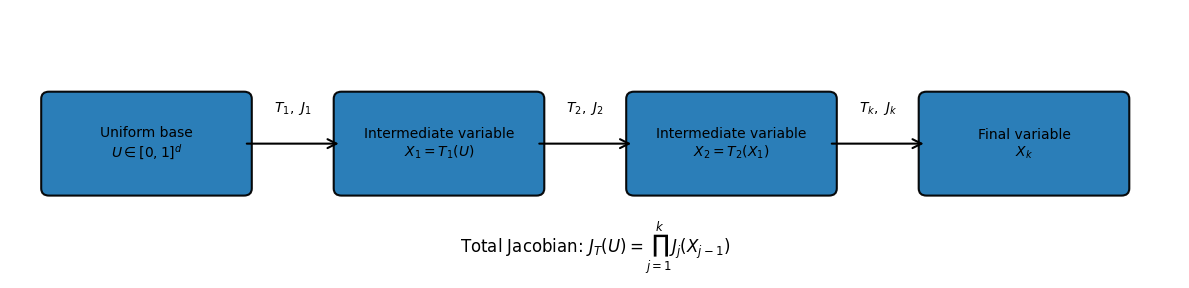

In [15]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.set_xlim(0, 12)
ax.set_ylim(0, 3)
ax.axis("off")

nodes = [
    (0.4, r"Uniform base" + "\n" + r"$U \in [0,1]^d$"),
    (3.4, r"Intermediate variable" + "\n" + r"$X_1 = T_1(U)$"),
    (6.4, r"Intermediate variable" + "\n" + r"$X_2 = T_2(X_1)$"),
    (9.4, r"Final variable" + "\n" + r"$X_k$"),
]

arrows = [
    (2.4, 3.4, r"$T_1,\ J_1$"),
    (5.4, 6.4, r"$T_2,\ J_2$"),
    (8.4, 9.4, r"$T_k,\ J_k$"),
]

# Draw nodes
for x_position, node_label in nodes:
    box = FancyBboxPatch(
        (x_position, 1.0),
        2.0,
        1.0,
        boxstyle="round,pad=0.08",
        linewidth=1.5,
        edgecolor="black",
        facecolor="#1f77b4",
        alpha=0.95,
    )
    ax.add_patch(box)
    ax.text(
        x_position + 1.0,
        1.5,
        node_label,
        ha="center",
        va="center",
        fontsize=10,
        color="black",
    )

# Draw arrows
for start, end, arrow_label in arrows:
    arrow = FancyArrowPatch(
        (start, 1.5),
        (end, 1.5),
        arrowstyle="->",
        mutation_scale=16,
        linewidth=1.5,
        color="black",
    )
    ax.add_patch(arrow)
    ax.text(
        (start + end) / 2,
        1.9,
        arrow_label,
        ha="center",
        va="center",
        fontsize=10,
    )

# Add total Jacobian text once
ax.text(
    6,
    0.35,
    r"Total Jacobian: $J_T(U)=\prod_{j=1}^{k} J_j(X_{j-1})$",
    ha="center",
    va="center",
    fontsize=12,
)

plt.tight_layout()
plt.show()

# 6. Two different meanings of inserting a transformation

Suppose the current transformation is

$$
X=T(U).
$$

A user may want to introduce another map for two different reasons.

## 6.1 Refactor the same transport

The first goal is to represent the same total map as a composition:

$$
T=R\circ S.
$$

Then

$$
U
\xrightarrow{S}
Y
\xrightarrow{R}
X
$$

still produces

$$
X=T(U).
$$

If $S$ is invertible, one possible construction is

$$
R=T\circ S^{-1}.
$$

This operation changes the internal factorization but preserves the final pushforward measure.

## 6.2 Replace the sampling transport

The second goal is to use a different sampling distribution.

Originally,

$$
X_p=T_p(U)\sim p.
$$

The integral is

$$
I
=
\int_{[0,1]^d}
g(T_p(u))
\,du.
$$

Suppose the direct target transform produces a difficult unit-cube integrand. We instead choose

$$
X_q=T_q(U)\sim q.
$$

Then

$$
I
=
\int_{[0,1]^d}
g(T_q(u))
\frac{p(T_q(u))}
     {q(T_q(u))}
\,du.
$$

Here, $T_q$ does not preserve the original map $T_p$. It changes the proposal and compensates through the likelihood ratio.

## 6.3 Why the distinction matters

These operations require different software semantics:

| Operation | Final map preserved? | Weight correction required? |
|---|---:|---:|
| Refactor a transport | Yes | No additional importance ratio |
| Insert a map and adjust an adjacent map | Yes | No additional importance ratio |
| Replace the proposal | No | Yes |
| Approximate transport plus correction | Not necessarily | Yes |

A future API should not silently treat these cases as equivalent.

# 7. Domain, range, and support compatibility

For a composition

$$
T_j\circ T_{j-1}
$$

to be well-defined, every output of $T_{j-1}$ must be a valid input to $T_j$.

A basic compatibility condition is therefore

$$
\operatorname{range}(T_{j-1})
\subseteq
\operatorname{domain}(T_j).
$$

Exact equality,

$$
\operatorname{range}(T_{j-1})
=
\operatorname{domain}(T_j),
$$

is sufficient but may be stronger than necessary.

However, set inclusion alone does not guarantee a valid change-of-variables calculation. We also need:

1. matching dimensions;
2. $T_j$ to be defined almost everywhere on the preceding range;
3. appropriate differentiability;
4. a usable Jacobian determinant or equivalent density relation;
5. correct treatment of open, closed, and infinite boundaries;
6. invertibility when an inverse change-of-variables formula is required.

## Importance-sampling support condition

If $q$ is the proposal density, then

$$
q(x)>0
$$

must hold wherever

$$
g(x)\lambda(x)\neq 0.
$$

Equivalently,

$$
\operatorname{supp}(g\lambda)
\subseteq
\operatorname{supp}(q).
$$

This condition is different from transformation-domain compatibility.

- Domain compatibility determines whether maps can be composed.
- Support coverage determines whether an importance ratio is valid.

# 8. Why an ordinary Pareto proposal is problematic

A standard Pareto distribution has support

$$
[x_m,\infty).
$$

A Gaussian target has support

$$
(-\infty,\infty).
$$

Therefore, an ordinary one-sided Pareto proposal does not cover the negative half of the Gaussian target domain.

It cannot directly be used for a general Gaussian expectation.

A better first heavy-tailed proposal would be:

- Student-$t$,
- Cauchy,
- Laplace,
- or a symmetric Pareto-like distribution.

These distributions have support on the full real line.

For the first QMCPy example, Student-$t$ is a convenient choice because it is heavier-tailed than a Gaussian and is directly available in SciPy.

# 9. Worked example: a Gaussian target with tail growth

Let

$$
X\sim N(0,1),
$$

and define

$$
g(x)=e^{x^2/4}.
$$

We want to estimate

$$
I
=
\mathbb E_{\phi}[g(X)]
=
\int_{\mathbb R}
e^{x^2/4}\phi(x)\,dx,
$$

where $\phi$ is the standard Gaussian density.

For $X\sim N(0,1)$,

$$
\mathbb E[e^{aX^2}]
=
\frac{1}{\sqrt{1-2a}},
\qquad
a<\frac12.
$$

Setting

$$
a=\frac14
$$

gives

$$
I
=
\frac{1}{\sqrt{1-\frac12}}
=
\sqrt{2}.
$$

Thus, the exact value is

$$
I=\sqrt{2}.
$$

This example is useful because:

1. the target value is known analytically;
2. $g(x)$ grows in both tails;
3. the Gaussian inverse CDF sends unit-interval endpoints to infinity;
4. the direct transformed integrand becomes large near $u=0$ and $u=1$;
5. a heavier-tailed proposal can change the boundary behavior.

# 10. Direct Gaussian transformation

Let

$$
U\sim\operatorname{Uniform}(0,1).
$$

The Gaussian inverse-CDF transformation is

$$
X=\Phi^{-1}(U),
$$

where $\Phi$ is the standard Gaussian CDF.

The transformed integrand becomes

$$
g(\Phi^{-1}(u)).
$$

Therefore,

$$
\int_0^1
g(\Phi^{-1}(u))
,du.
$$

Because

$$
\Phi^{-1}(u)\rightarrow-\infty
$$

as

$$
u\rightarrow 0,
$$

and

$$
\Phi^{-1}(u)\rightarrow\infty
$$

as

$$
u\rightarrow 1,
$$

the transformed function

$$
g(\Phi^{-1}(u))
$$

becomes large near both endpoints.

This can produce boundary singularities or poor smoothness on the unit interval.

# 11. Student-$t$ importance proposal

Let $q$ be a Student-$t$ density with three degrees of freedom.

Define

$$
X=F_{t_3}^{-1}(U),
$$

where $F_{t_3}$ is the Student-$t$ CDF.

Then

$$
X\sim q.
$$

The importance-sampling identity is

$$
\mathbb E_q
\left[
g(X)
\frac{\phi(X)}
{q(X)}
\right],
$$

where $\phi$ is the standard Gaussian density.

On the unit interval,

$$
\int_0^1
g(F_{t_3}^{-1}(u))
\frac{
\phi(F_{t_3}^{-1}(u))
}{
q(F_{t_3}^{-1}(u))
}
,du.
$$

Define

$$
g(F_{t_3}^{-1}(u))
\frac{
\phi(F_{t_3}^{-1}(u))
}{
q(F_{t_3}^{-1}(u))
}.
$$

This transformed integrand represents the same original Gaussian expectation but uses a heavier-tailed sampling distribution.

In [16]:
## Compute the transformed integrands

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Avoid evaluating inverse CDFs exactly at 0 and 1.
epsilon = 1e-6
u = np.linspace(epsilon, 1.0 - epsilon, 4000)

# Exact value:
# E[exp(X^2 / 4)] = sqrt(2), where X ~ N(0, 1).
exact_value = np.sqrt(2.0)


# ---------------------------------------------------------
# Direct Gaussian transport
# U ~ Uniform(0, 1) -> X ~ N(0, 1)
# ---------------------------------------------------------

x_gaussian = stats.norm.ppf(u)

direct_integrand = np.exp(
    x_gaussian**2 / 4.0
)


# ---------------------------------------------------------
# Student-t importance proposal
# U ~ Uniform(0, 1) -> X ~ t_df
#
# Corrected integrand:
# g(X) * target_pdf(X) / proposal_pdf(X)
# ---------------------------------------------------------

student_df = 3

x_student = stats.t.ppf(
    u,
    df=student_df,
)

# Compute the importance correction in log-space to avoid
# numerical overflow from exp(x^2 / 4) in the tails.
log_student_integrand = (
    x_student**2 / 4.0
    + stats.norm.logpdf(x_student)
    - stats.t.logpdf(x_student, df=student_df)
)

student_integrand = np.exp(
    log_student_integrand
)


# ---------------------------------------------------------
# Numerical summaries
# ---------------------------------------------------------

print(f"Exact integral: {exact_value:.10f}")

print(
    "Direct Gaussian transformed integrand range: "
    f"[{direct_integrand.min():.6f}, "
    f"{direct_integrand.max():.6f}]"
)

print(
    "Student-t importance integrand range: "
    f"[{student_integrand.min():.6f}, "
    f"{student_integrand.max():.6f}]"
)

Exact integral: 1.4142135624
Direct Gaussian transformed integrand range: [1.000000, 283.939352]
Student-t importance integrand range: [0.000000, 2.211361]


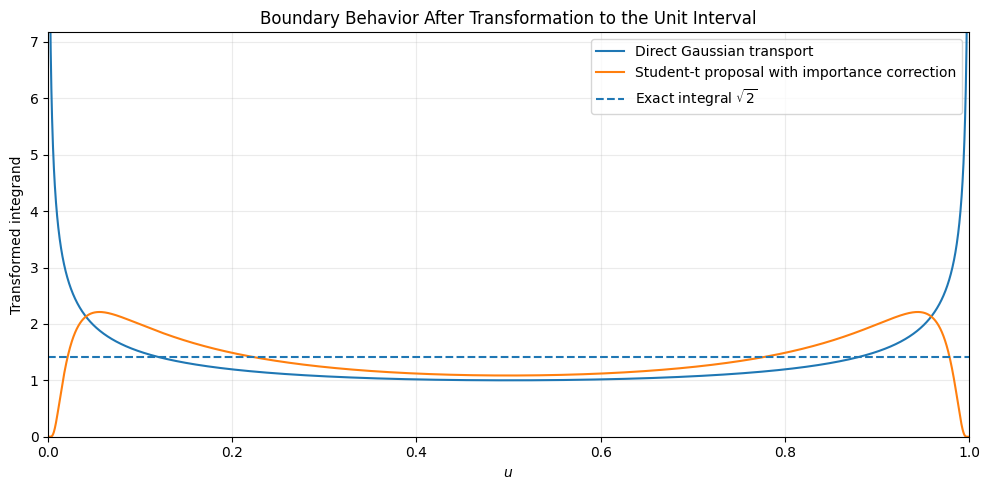

In [17]:
## Plot the boundary behavior

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    u,
    direct_integrand,
    label="Direct Gaussian transport",
    linewidth=1.5,
)

ax.plot(
    u,
    student_integrand,
    label="Student-t proposal with importance correction",
    linewidth=1.5,
)

ax.axhline(
    exact_value,
    linestyle="--",
    linewidth=1.5,
    label=r"Exact integral $\sqrt{2}$",
)

# Limit the vertical axis so that the interior behavior
# remains visible despite the direct transform's boundary spikes.
upper_limit = min(
    20.0,
    np.quantile(direct_integrand, 0.995),
)

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, upper_limit)

ax.set_xlabel(r"$u$")
ax.set_ylabel("Transformed integrand")

ax.set_title(
    "Boundary Behavior After Transformation "
    "to the Unit Interval"
)

ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

plt.show()

### Interpretation

The plot does not prove that Student-$t$ is the optimal proposal.

It demonstrates the reason for supporting flexible proposals:

- the original function $g$ remains unchanged;
- the sampling transformation can be changed;
- the necessary density ratio is applied automatically;
- the behavior of the resulting unit-cube integrand can change substantially;
- users should not need to hardcode the importance ratio inside $g$.

# 12. Scrambled Sobol comparison

The following experiment compares:

- direct Gaussian inverse-CDF sampling;
- Student-$t$ proposal sampling with importance correction.

Each estimate uses a scrambled Sobol sequence.

Multiple independent scrambles are used to observe the empirical variation.

In [18]:
# Direct Gaussian transport estimator

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import qmc

exact_value = np.sqrt(2.0)


def sobol_estimate_direct(m, seed):
    """
    Estimate E[exp(X^2 / 4)] for X ~ N(0, 1)
    using a scrambled Sobol sequence.

    Parameters
    ----------
    m : int
        Number of Sobol points is n = 2**m.
    seed : int
        Random seed used for Sobol scrambling.

    Returns
    -------
    float
        QMC estimate of the integral.
    """
    sampler = qmc.Sobol(
        d=1,
        scramble=True,
        seed=seed,
    )

    u = sampler.random_base2(m=m).reshape(-1)

    # Prevent norm.ppf from being evaluated at exactly 0 or 1.
    machine_epsilon = np.finfo(float).eps
    u = np.clip(
        u,
        machine_epsilon,
        1.0 - machine_epsilon,
    )

    x = stats.norm.ppf(u)

    values = np.exp(x**2 / 4.0)

    return np.mean(values)

In [19]:
# Student-t importance-sampling estimator

def sobol_estimate_student(m, seed, df=3):
    """
    Estimate E_phi[exp(X^2 / 4)] using a Student-t proposal
    and scrambled Sobol points.

    Parameters
    ----------
    m : int
        Number of Sobol points is n = 2**m.
    seed : int
        Random seed used for Sobol scrambling.
    df : float, default=3
        Degrees of freedom of the Student-t proposal.

    Returns
    -------
    float
        Importance-sampling QMC estimate of the integral.
    """
    sampler = qmc.Sobol(
        d=1,
        scramble=True,
        seed=seed,
    )

    u = sampler.random_base2(m=m).reshape(-1)

    # Prevent t.ppf from being evaluated at exactly 0 or 1.
    machine_epsilon = np.finfo(float).eps
    u = np.clip(
        u,
        machine_epsilon,
        1.0 - machine_epsilon,
    )

    # Transform uniform Sobol points through the Student-t inverse CDF.
    x = stats.t.ppf(
        u,
        df=df,
    )

    # Compute the corrected integrand in log-space:
    #
    # log[g(x) * phi(x) / q(x)]
    # = x^2 / 4 + log(phi(x)) - log(q(x)).
    log_values = (
        x**2 / 4.0
        + stats.norm.logpdf(x)
        - stats.t.logpdf(x, df=df)
    )

    values = np.exp(log_values)

    return np.mean(values)

In [20]:
# Run scrambled Sobol replications

# Each replication uses n = 2**m Sobol points.
m = 10
sample_size = 2**m

# Use independent Sobol scrambles to estimate empirical variability.
seeds = np.arange(32)

direct_estimates = np.array(
    [
        sobol_estimate_direct(
            m=m,
            seed=int(seed),
        )
        for seed in seeds
    ]
)

student_estimates = np.array(
    [
        sobol_estimate_student(
            m=m,
            seed=int(seed),
            df=3,
        )
        for seed in seeds
    ]
)

# Empirical root mean squared error across scramble replications.
direct_rmse = np.sqrt(
    np.mean(
        (direct_estimates - exact_value) ** 2
    )
)

student_rmse = np.sqrt(
    np.mean(
        (student_estimates - exact_value) ** 2
    )
)

print(f"Samples per replication: {sample_size}")
print(f"Number of replications: {len(seeds)}")
print(f"Exact value: {exact_value:.10f}")
print()

print(
    "Direct Gaussian estimate mean: "
    f"{direct_estimates.mean():.10f}"
)

print(
    "Direct Gaussian empirical RMSE: "
    f"{direct_rmse:.6e}"
)

print()

print(
    "Student-t estimate mean: "
    f"{student_estimates.mean():.10f}"
)

print(
    "Student-t empirical RMSE: "
    f"{student_rmse:.6e}"
)

Samples per replication: 1024
Number of replications: 32
Exact value: 1.4142135624

Direct Gaussian estimate mean: 1.4111454721
Direct Gaussian empirical RMSE: 1.625730e-02

Student-t estimate mean: 1.4141969015
Student-t empirical RMSE: 1.704206e-04


The comparison is based on one fixed integrand, one proposal family, a fixed sample size, and a fixed collection of scramble seeds. It is an empirical illustration of transformed-integrand behavior, not a theoretical variance comparison or a general claim that Student-$t$ proposals are always preferable.

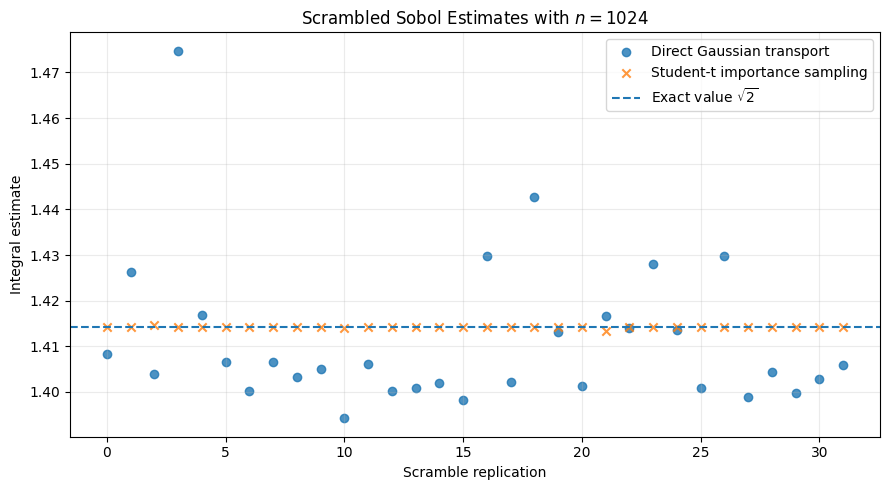

In [21]:
# Compare the estimates visually

fig, ax = plt.subplots(figsize=(9, 5))

replication_ids = np.arange(len(seeds))

ax.scatter(
    replication_ids,
    direct_estimates,
    label="Direct Gaussian transport",
    marker="o",
    alpha=0.8,
)

ax.scatter(
    replication_ids,
    student_estimates,
    label="Student-t importance sampling",
    marker="x",
    alpha=0.8,
)

ax.axhline(
    exact_value,
    linestyle="--",
    linewidth=1.5,
    label=r"Exact value $\sqrt{2}$",
)

ax.set_xlabel("Scramble replication")
ax.set_ylabel("Integral estimate")

ax.set_title(
    f"Scrambled Sobol Estimates with $n={sample_size}$"
)

ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## Numerical observation

Using $n=1024$ points and 32 independent scrambled Sobol replications, this experiment produced:

| Method | Mean estimate | Empirical RMSE |
|---|---:|---:|
| Direct Gaussian inverse-CDF transform | approximately $1.41115$ | approximately $1.63\times10^{-2}$ |
| Student-$t_3$ proposal with importance correction | approximately $1.41420$ | approximately $1.70\times10^{-4}$ |

The exact value is

$$
\sqrt{2}\approx1.4142135624.
$$

For this specific integrand and these settings, the Student-$t$ proposal substantially reduced the empirical variation across scrambles.

This is an illustrative example, not a general claim that Student-$t$ proposals always outperform direct Gaussian transformations. Importance-sampling performance depends on the relationship among:

- the target weight;
- the integrand;
- the proposal;
- the transformed unit-cube smoothness;
- and the numerical integration method.

# 13. Importance sampling with an unnormalized target weight

Suppose the normalized target density is

$$
p(x)
=
\frac{\lambda(x)}{Z},
$$

where

$$
Z
=
\int_{\mathcal X}
\lambda(x)\,dx
$$

is unknown.

Equivalently,

$$
\lambda(x)=Zp(x).
$$

The function $\lambda$ is available pointwise, but its normalizing constant is not.

Two different estimation problems must be distinguished.

## 13.1 Estimating an unnormalized integral

Consider

$$
A
=
\int_{\mathcal X}
g(x)\lambda(x)\,dx.
$$

If $X\sim q$, then

$$
A
=
\mathbb E_q
\left[
g(X)
\frac{\lambda(X)}
     {q(X)}
\right].
$$

This is still a linear integration problem. Knowledge of $Z$ is not required.

## 13.2 Estimating an expectation under the normalized target

The desired expectation is

$$
\mu
=
\mathbb E_p[g(X)].
$$

Since

$$
p(x)
=
\frac{\lambda(x)}{Z},
$$

we obtain

$$
\mu
=
\frac{
\int g(x)\lambda(x)\,dx
}{
\int \lambda(x)\,dx
}.
$$

Define

$$
A
=
\int g(x)\lambda(x)\,dx
$$

and

$$
B
=
\int \lambda(x)\,dx.
$$

Then

$$
\mu=\frac{A}{B}.
$$

Using proposal density $q$,

$$
A
=
\mathbb E_q
\left[
g(X)\frac{\lambda(X)}{q(X)}
\right],
$$

and

$$
B
=
\mathbb E_q
\left[
\frac{\lambda(X)}{q(X)}
\right].
$$

The corresponding sample estimator is

$$
\widehat{\mu}_n
=
\frac{
\sum_{i=1}^{n}
g(X_i)w_i
}{
\sum_{i=1}^{n}
w_i
},
\qquad
w_i
=
\frac{\lambda(X_i)}
     {q(X_i)}.
$$

This is self-normalized importance sampling.

# 14. A vector-valued QMCPy formulation

A natural QMCPy formulation is to define the two-output function

$$
H(x)
=
\begin{bmatrix}
H_1(x) \\
H_2(x)
\end{bmatrix}
=
\begin{bmatrix}
g(x)\lambda(x)/q(x) \\
\lambda(x)/q(x)
\end{bmatrix}.
$$

The expectations of the two components are

$$
A
=
\mathbb E_q[H_1(X)]
=
\int g(x)\lambda(x)\,dx,
$$

and

$$
B
=
\mathbb E_q[H_2(X)]
=
\int \lambda(x)\,dx.
$$

The normalized target expectation is then

$$
\mu
=
\frac{A}{B}.
$$

Within QMCPy, the individual output dimension could represent $(A,B)$, while the combined output could represent the ratio $A/B$.

This suggests using:

- a two-component individual integrand;
- a `bound_fun` that maps bounds on $(A,B)$ to a bound on $A/B$;
- a dependency function indicating that both components must be refined when the ratio tolerance is not satisfied.

The main unresolved issue is how to propagate rigorous or reliable error bounds through the nonlinear ratio.

# 15. Worked unnormalized example

Consider the unnormalized Gaussian weight

$$
\lambda(x) = e^{-x^2/2}.
$$

This weight is proportional to the standard Gaussian density, but it does not include the normalizing constant. Its normalizing integral is

$$
\begin{aligned}
Z
&= \int_{-\infty}^{\infty} \lambda(x)\,dx \\
&= \int_{-\infty}^{\infty} e^{-x^2/2}\,dx \\
&= \sqrt{2\pi}.
\end{aligned}
$$

The corresponding normalized density is

$$
\begin{aligned}
p(x)
&= \frac{\lambda(x)}{Z} \\
&= \frac{1}{\sqrt{2\pi}}e^{-x^2/2},
\end{aligned}
$$

which is the standard Gaussian density.

Choose the integrand

$$
g(x) = x^2.
$$

The desired normalized expectation is

$$
\mathbb{E}_p[g(X)]
=
\mathbb{E}_p[X^2].
$$

Since

$$
X \sim \mathcal{N}(0,1),
$$

the exact value is

$$
\mathbb{E}_p[X^2] = 1.
$$

Using the unnormalized weight, this expectation can also be written as the ratio

$$
\mathbb{E}_p[X^2]
=
\frac{
\displaystyle \int_{-\infty}^{\infty}
x^2 e^{-x^2/2}\,dx
}{
\displaystyle \int_{-\infty}^{\infty}
e^{-x^2/2}\,dx
}.
$$

For the numerical experiment, use a Student-$t$ proposal with three degrees of freedom:

$$
q(x) = t_3(x).
$$

The numerator and denominator can then be written as expectations under $q$:

$$
A
=
\mathbb{E}_q
\left[
X^2\frac{\lambda(X)}{q(X)}
\right],
$$

and

$$
B
=
\mathbb{E}_q
\left[
\frac{\lambda(X)}{q(X)}
\right].
$$

The self-normalized importance-sampling estimate is

$$
\widehat{\mu}
=
\frac{\widehat{A}}{\widehat{B}}.
$$

For this example, the exact reference values are

$$
A = \sqrt{2\pi},
\qquad
B = \sqrt{2\pi},
\qquad
\frac{A}{B} = 1.
$$

In [22]:
# Self-normalized importance-sampling estimate

import numpy as np
from scipy import stats
from scipy.stats import qmc

# Student-t proposal parameters
student_df = 3

# Generate n = 2**m scrambled Sobol points
m = 13
sample_size = 2**m

sampler = qmc.Sobol(
    d=1,
    scramble=True,
    seed=11,
)

u = sampler.random_base2(m=m).reshape(-1)

# Prevent the inverse CDF from being evaluated at exactly 0 or 1
machine_epsilon = np.finfo(float).eps

u = np.clip(
    u,
    machine_epsilon,
    1.0 - machine_epsilon,
)

# Transform the Sobol points through the Student-t inverse CDF
x = stats.t.ppf(
    u,
    df=student_df,
)

# Unnormalized target:
# lambda(x) = exp(-x^2 / 2)
#
# Importance weight:
# lambda(x) / q(x)
#
# Compute the weights in log-space for numerical stability.
log_weights = (
    -0.5 * x**2
    - stats.t.logpdf(x, df=student_df)
)

weights = np.exp(log_weights)

# Vector-integrand components
numerator_contributions = x**2 * weights
denominator_contributions = weights

# Estimate A and B
numerator_estimate = np.mean(numerator_contributions)
denominator_estimate = np.mean(denominator_contributions)

# Self-normalized estimate A_hat / B_hat
self_normalized_estimate = (
    numerator_estimate
    / denominator_estimate
)

known_normalizing_integral = np.sqrt(2.0 * np.pi)
exact_expectation = 1.0

print(f"Samples: {sample_size}")
print(
    "Estimated unnormalized numerator: "
    f"{numerator_estimate:.10f}"
)
print(
    "Estimated normalizing integral: "
    f"{denominator_estimate:.10f}"
)
print(
    "Known normalizing integral: "
    f"{known_normalizing_integral:.10f}"
)
print(
    "Self-normalized estimate of E[X^2]: "
    f"{self_normalized_estimate:.10f}"
)
print(
    "Exact normalized expectation: "
    f"{exact_expectation:.10f}"
)

Samples: 8192
Estimated unnormalized numerator: 2.5066282255
Estimated normalizing integral: 2.5066282717
Known normalizing integral: 2.5066282746
Self-normalized estimate of E[X^2]: 0.9999999816
Exact normalized expectation: 1.0000000000


In [23]:
# Store and inspect the vector-valued integrand

# Each row contains:
# [x^2 * lambda(x) / q(x), lambda(x) / q(x)]
vector_integrand_values = np.column_stack(
    (
        numerator_contributions,
        denominator_contributions,
    )
)

component_estimates = vector_integrand_values.mean(axis=0)

print("First five rows:")
print(vector_integrand_values[:5])

print("\nComponent-wise estimates:")
print(component_estimates)

print(
    "\nNumerator estimate: "
    f"{component_estimates[0]:.10f}"
)
print(
    "Denominator estimate: "
    f"{component_estimates[1]:.10f}"
)
print(
    "Ratio estimate: "
    f"{component_estimates[0] / component_estimates[1]:.10f}"
)

First five rows:
[[0.477394 2.79063 ]
 [1.021515 2.850213]
 [5.056908 2.835656]
 [2.846933 2.933506]
 [6.413568 2.64716 ]]

Component-wise estimates:
[2.506628 2.506628]

Numerator estimate: 2.5066282255
Denominator estimate: 2.5066282717
Ratio estimate: 0.9999999816


# 16. Multidimensional formulation

Let

$$
u,x\in\mathbb R^d.
$$

Each transformation is

$$
T_j:
\mathcal X_{j-1}
\rightarrow
\mathcal X_j.
$$

Its Jacobian is the matrix

$$
DT_j(x_{j-1})
\in
\mathbb R^{d\times d}.
$$

The Jacobian factor is

$$
\left|
\det DT_j(x_{j-1})
\right|.
$$

For a chain,

$$
T_k
\circ
\cdots
\circ
T_1,
$$

the total factor is

$$
\prod_{j=1}^{k}
J_j(x_{j-1}).
$$

## 16.1 Independent componentwise transformations

Suppose

$$
\left(
T_{j,1}(x_1),
\ldots,
T_{j,d}(x_d)
\right).
$$

The Jacobian matrix is diagonal:

$$
\begin{bmatrix}
T_{j,1}'(x_1) & 0 & \cdots & 0 \
0 & T_{j,2}'(x_2) & \cdots & 0 \
\vdots & \vdots & \ddots & \vdots \
0 & 0 & \cdots & T_{j,d}'(x_d)
\end{bmatrix}.
$$

Therefore,

$$
\prod_{\ell=1}^{d}
\left|
T_{j,\ell}'(x_\ell)
\right|.
$$

This matches the type of product currently used by many independent TrueMeasure implementations.

## 16.2 Dependent transformations

For dependent transformations, the Jacobian may not be diagonal.

Examples include:

- Gaussian copula transforms;
- Student-$t$ copulas;
- Rosenblatt transforms;
- inverse Rosenblatt transforms;
- triangular transport maps;
- general normalizing-flow layers.

For these transformations, the full determinant is required:

$$
\left|
\det DT_j(x)
\right|.
$$

A general interface should therefore not assume that every Jacobian can be calculated as a product of one-dimensional derivatives.

## 16.3 Log-Jacobians

Products of many Jacobians can underflow or overflow.

A more numerically stable representation is

$$
\sum_{j=1}^{k}
\log J_j(x_{j-1}).
$$

The final Jacobian can be recovered using

$$
\exp\left(
\log J_T(u)
\right).
$$

A possible transformation interface could therefore provide

`log_abs_det_jacobian(x)`

instead of only returning a direct Jacobian factor.

# 17. Proposed transformation contract

Each transformation should clearly define the following information.

| Property | Meaning |
|---|---|
| `domain` | Set on which the forward map is valid |
| `range` | Set produced by the forward map |
| `dimension` | Input and output dimensions |
| `forward(x)` | Forward deterministic transformation |
| `inverse(y)` | Optional inverse transformation |
| `log_abs_det_jacobian(x)` | Log absolute determinant of the forward Jacobian |
| `weight(y)` | Target-measure weight |
| `normalized` | Whether the weight includes its normalizing constant |

A major design question is whether the current `TrueMeasure` class combines two distinct roles:

1. A deterministic transport map
2. A measure weight used by the integrand

The current `_transform` and `_weight` methods can represent many cases, but the mathematical relationship between them should be documented more explicitly.

> **Important:** The APIs in the next two sections are conceptual design sketches. They are not currently implemented QMCPy classes or confirmed constructor signatures.

# 18. Possible API direction A

The first option is to retain the existing TrueMeasure architecture and clarify its contract.

Conceptually:

```python
proposal = HeavyTailedProposal(
    sampler=DigitalNetB2(d),
    parameters=...,
)

target = GaussianTarget(
    sampler=proposal,
    mean=np.zeros(d),
    covariance=np.eye(d),
)

integrand = CustomFunction(
    true_measure=target,
    g=g,
)
```

The purpose of this sketch is to illustrate the intended responsibilities, not to prescribe exact class names.

Under this design, the existing `TrueMeasure` machinery would ideally be responsible for:

1. generating samples through the proposal transformation;
2. accumulating the required Jacobian factors;
3. evaluating the target weight;
4. dividing by the induced proposal density;
5. preserving the original user-defined function $g$.

The main implementation question is whether the current `TrueMeasure` contract already supports these responsibilities clearly enough or whether additional metadata and validation are required.

# 19. Possible API direction B

A second option is to introduce an explicit transport abstraction.

For example:

```python
# Conceptual pseudocode, not current QMCPy syntax

transport = ComposedTransport(
    transforms=[
        BaseToProposal(...),
        IntermediateTransform(...),
        FinalTransform(...),
    ]
)

samples, log_jacobian = transport.forward_and_log_jacobian(
    uniform_samples
)
```

Each component could expose:

- `forward(x)`

- `inverse(y)`

- `log_abs_det_jacobian(x)`

- `domain`

- `range`

This resembles normalizing-flow libraries but does not require neural networks or automatic differentiation.

The first implementation could use only NumPy, SciPy, and analytic Jacobians.

> The discussion of normalizing flows is included only to explore whether the existing `TrueMeasure` architecture can be interpreted as a sequence of transport maps.

> The objective of this work is **not** to introduce neural normalizing flows into QMCPy, but to understand whether similar mathematical ideas can clarify or extend the current recursive transformation framework.

# 20. Relationship to normalizing flows

Normalizing flows provide a useful conceptual connection, but they are not the initial implementation target.

A normalizing flow begins with a tractable base variable

$$
X_0\sim p_0
$$

and applies a sequence of bijective differentiable maps,

$$
X_j=T_j(X_{j-1}),
\qquad
j=1,\ldots,k.
$$

The complete map is

$$
T=T_k\circ\cdots\circ T_1.
$$

The final density satisfies

$$
\log p_k(x_k)
=
\log p_0(x_0)
-
\sum_{j=1}^{k}
\log
\left|
\det DT_j(x_{j-1})
\right|.
$$

This is closely related to the same recursive Jacobian accounting required for chained `TrueMeasure` transformations.

The difference is primarily in scope and implementation.

Modern normalizing-flow systems often include:

- trainable transformations;
- automatic differentiation;
- GPU tensor execution;
- optimization loops;
- neural-network parameterizations.

QMCPy currently uses NumPy and SciPy and does not provide a PyTorch-style automatic-differentiation framework.

Therefore, the proposed first step is narrower:

1. deterministic analytic transformations;
2. explicit composition;
3. user-provided or analytic Jacobians;
4. proposal changes with importance correction;
5. normalized and unnormalized weights;
6. multidimensional support where mathematically clear.

This can create a mathematically consistent foundation that could later connect to external normalizing-flow tools without making QMCPy itself a neural-flow framework.

# 21. Proposed first milestone

The first contribution should answer one small, testable question:

> Can the current QMCPy architecture express an integral under a Gaussian target using a heavy-tailed proposal while leaving the user-supplied function $g$ unchanged?

## Proposed work

1. Reproduce the existing composed Kumaraswamy example.
2. Trace the recursive transformations, weights, and Jacobian factors used by the current implementation.
3. Prototype a Gaussian target with a Student-$t$ proposal.
4. Confirm whether QMCPy automatically constructs the equivalent of

   $$
   g(x)\frac{\phi(x)}{q(x)},
   $$

   where $\phi$ is the Gaussian target density and $q$ is the Student-$t$ proposal density.

5. Use the analytically verifiable example

   $$
   g(x)=e^{x^2/4},
   \qquad
   I=\sqrt{2}.
   $$

6. Add tests for:
   - output shape;
   - one-dimensional behavior;
   - an independent multidimensional case;
   - finite transformed values;
   - support compatibility;
   - agreement with the analytic result.

7. Prototype an unnormalized target using a two-output numerator-and-denominator integrand.
8. Determine whether the existing `bound_fun` and combined-output machinery can propagate error bounds through the ratio or whether stopping-criterion changes are required.

## Not included in the first milestone

The first contribution will not attempt to implement:

- trainable neural normalizing flows;
- automatic differentiation;
- PyTorch or JAX dependencies;
- GPU execution;
- learned optimal transports;
- arbitrary signed measures;
- arbitrary noninvertible transformations;
- general nonrectangular support objects.

# 22. Decisions needed before implementation

## Mathematical decisions

1. Are we primarily generalizing deterministic transport composition, importance sampling, or both?
2. When should a transformation chain preserve the same final pushforward measure?
3. Is range inclusion sufficient for composition, or do we need a richer compatibility contract?
4. Must every transformation be invertible?
5. Should Jacobians be supplied directly or as log absolute determinants?
6. Should the first multidimensional version be limited to componentwise or triangular maps?

## QMCPy design decisions

7. Does `TrueMeasure` currently combine too many responsibilities:
   - transport,
   - proposal density,
   - target weight,
   - and support metadata?

8. Should `_weight` include metadata indicating whether it is normalized?
9. Should proposal support coverage be validated separately from domain compatibility?
10. Should an explicit transport class be introduced, or should the current `TrueMeasure` contract be clarified?
11. Can the existing vector-valued integrand and `bound_fun` interfaces support self-normalized importance sampling?
12. Where should the numerator/denominator ratio be formed:
   - inside the integrand,
   - inside a stopping criterion,
   - or as a combined solution?

## Scope decisions

13. Is the Gaussian target with Student-$t$ proposal an appropriate first example?
14. Should this work open one combined issue or two separate issues?
15. Should Issue #174 be referenced as historical motivation rather than updated directly?

# 23. Suggested future GitHub issues

The current investigation suggests two largely independent implementation directions.

### Issue A: Generalizing chained `TrueMeasure` transformations using transport maps

This issue would focus on:

- transformation-chain mathematics;
- domain and range compatibility;
- Jacobian accumulation;
- multidimensional composition;
- examples beyond Kumaraswamy;
- support inclusion;
- transport-map terminology.

### Issue B: Importance sampling with normalized and unnormalized target weights

This issue would reference Issue #174 and distinguish:

- normalized importance sampling;
- unnormalized integral estimation;
- self-normalized importance sampling;
- numerator and denominator estimation;
- ratio error propagation;
- user-defined unnormalized weights.

The two issues are related, but they solve different mathematical and software problems.

# 24. Conclusion and proposed next step

QMCPy already contains several components needed for more general importance sampling and measure transport:

- recursive `TrueMeasure` composition;
- recursive Jacobian or inverse-density accumulation;
- an importance-sampling branch in `AbstractIntegrand.f`;
- vector-valued integrands and combined outputs;
- nonprobability measure weights through `Lebesgue`.

The current gap is not simply a missing importance-sampling formula.

The main gap is the absence of a precise and documented contract separating:

1. the deterministic transformation;
2. the distribution induced by that transformation;
3. the target measure weight;
4. the proposal density;
5. compatibility between adjacent transformation spaces;
6. proposal support coverage;
7. normalized and unnormalized target weights.

The numerical example demonstrates why flexible proposal transformations may be useful. For

$$
g(x)=e^{x^2/4},
\qquad
X\sim N(0,1),
$$

the direct Gaussian inverse-CDF transformation produces a transformed integrand that increases rapidly near the unit-interval boundaries.

For this particular integrand, proposal distribution, sample size, and collection of scrambled Sobol sequences, the Student-$t$ proposal produced substantially lower empirical RMSE than the direct Gaussian transformation.

This observation motivates further investigation but should not be interpreted as a general statement about optimal proposal distributions.

The proposed next step is therefore:

1. verify whether the current QMCPy classes can express this example without modifying $g$;
2. identify the smallest interface or validation limitation preventing it, if one exists;
3. implement only that minimal extension;
4. separately prototype an unnormalized target using a two-output numerator-and-denominator integrand;
5. use the results to define the scope of the new GitHub issues.

This approach provides a practical first step toward more general transport-map composition without requiring QMCPy to become a PyTorch-based normalizing-flow framework.

## Open questions

The notebook leaves several questions intentionally unresolved.

- Should transport maps become an explicit abstraction or remain part of `TrueMeasure`?
- Is exact domain equality necessary, or is set inclusion sufficient?
- Should Jacobians be represented directly or in logarithmic form?
- Can self-normalized importance sampling be incorporated through the current vector-valued integrand interface?
- What is the smallest implementation that provides meaningful new functionality while remaining consistent with the current QMCPy architecture?

These questions are intended to guide discussion before implementation begins.

## Requested feedback

Before implementation, I would appreciate feedback on three decisions:

1. whether the first contribution should focus primarily on importance sampling or on the broader transformation-composition contract;
2. whether the existing `TrueMeasure` abstraction should be extended or whether transport maps should be represented separately;
3. whether the Gaussian-target and Student-$t$-proposal example is an appropriate first test case for the package and for future Monte Carlo teaching material.

# References

## QMCPy implementation and project context

1. **QMCSoftware/QMCSoftware. `AbstractTrueMeasure`.**  
   File: [`qmcpy/true_measure/abstract_true_measure.py`](https://github.com/QMCSoftware/QMCSoftware/blob/develop/qmcpy/true_measure/abstract_true_measure.py)  
   Relevant methods:
   - `_parse_sampler`
   - `_jacobian_transform_r`

   This file is relevant for recursive `TrueMeasure` composition, domain/range compatibility checking, transformation application, and recursive Jacobian accumulation.

2. **QMCSoftware/QMCSoftware. `AbstractIntegrand`.**  
   File: [`qmcpy/integrand/abstract_integrand.py`](https://github.com/QMCSoftware/QMCSoftware/blob/develop/qmcpy/integrand/abstract_integrand.py)  
   Relevant method:
   - `AbstractIntegrand.f`

   This file is relevant for the current direct-transformation and importance-sampling evaluation paths.

3. **QMCSoftware/QMCSoftware. `Kumaraswamy`.**  
   File: [`qmcpy/true_measure/kumaraswamy.py`](https://github.com/QMCSoftware/QMCSoftware/blob/develop/qmcpy/true_measure/kumaraswamy.py)

   This class provides the existing example of a `TrueMeasure` whose domain and range are both the unit cube, allowing Kumaraswamy transformations to be composed.

4. **QMCSoftware/QMCSoftware. `Lebesgue`.**  
   File: [`qmcpy/true_measure/lebesgue.py`](https://github.com/QMCSoftware/QMCSoftware/blob/develop/qmcpy/true_measure/lebesgue.py)

   This class is relevant as a built-in measure whose `_weight` is identically one and is not a normalized probability density over an unbounded domain.

5. **QMCSoftware/QMCSoftware. `some_true_measures` demo.**  
   Notebook: [`demos/some_true_measures.ipynb`](https://github.com/QMCSoftware/QMCSoftware/blob/develop/demos/some_true_measures.ipynb)

   This notebook contains the existing one- and two-Kumaraswamy composition and importance-sampling examples.

6. **QMCSoftware/QMCSoftware. Issue #174.**  
   [Importance sampling with un-normalized density functions](https://github.com/QMCSoftware/QMCSoftware/issues/174)

   This issue records the distinction between ordinary importance sampling with normalized densities and self-normalized importance sampling with unnormalized target weights.

7. **QMCSoftware/QMCSoftware repository.**  
   [QMCPy GitHub repository](https://github.com/QMCSoftware/QMCSoftware)

   The repository contains the current package implementation, demonstrations, tests, and documentation.

8. **QMCPy documentation.**  
   [QMCPy documentation site](https://qmcsoftware.github.io/QMCSoftware/)

   The documentation provides the public package reference and rendered examples.

## Normalizing flows and change of variables

9. Papamakarios, G., Nalisnick, E., Rezende, D. J., Mohamed, S., and Lakshminarayanan, B.  
   **“Normalizing Flows for Probabilistic Modeling and Inference.”**  
   *Journal of Machine Learning Research*, 22(57):1–64, 2021.

   - [JMLR article page](https://www.jmlr.org/papers/v22/19-1028.html)
   - [JMLR PDF](https://www.jmlr.org/papers/volume22/19-1028/19-1028.pdf)
   - [arXiv:1912.02762](https://arxiv.org/abs/1912.02762)

   This review is relevant for composed bijective transformations, the change-of-variables formula, Jacobian determinants, inverse transformations, and computational tradeoffs in normalizing flows.

## Transport maps and importance sampling

10. Cotter, S. L., Kevrekidis, I. G., and Russell, P. T.  
    **“Transport Map Accelerated Adaptive Importance Sampling, and Application to Inverse Problems Arising from Multiscale Stochastic Reaction Networks.”**  
    *SIAM/ASA Journal on Uncertainty Quantification*, 8(4):1383–1413, 2020.

    - [DOI: 10.1137/19M1239416](https://doi.org/10.1137/19M1239416)
    - [SIAM article page](https://epubs.siam.org/doi/10.1137/19M1239416)

    This paper is relevant for combining deterministic transport maps with adaptive importance sampling and retaining an importance correction when the transport is approximate.

11. Parno, M. D., and Marzouk, Y. M.  
    **“Transport Map Accelerated Markov Chain Monte Carlo.”**  
    *SIAM/ASA Journal on Uncertainty Quantification*, 6(2):645–682, 2018.

    - [DOI: 10.1137/17M1134640](https://doi.org/10.1137/17M1134640)
    - [SIAM article page](https://epubs.siam.org/doi/10.1137/17M1134640)

    This paper is relevant for deterministic couplings, triangular transport maps, the Knothe–Rosenblatt rearrangement, and the use of transport maps to simplify non-Gaussian target distributions.

12. Cotter, C. J., Cotter, S. L., and Russell, P. T.  
    **“Ensemble Transport Adaptive Importance Sampling.”**  
    *SIAM/ASA Journal on Uncertainty Quantification*, 7(2):444–471, 2019.

    - [DOI: 10.1137/17M1114867](https://doi.org/10.1137/17M1114867)
    - [SIAM article page](https://epubs.siam.org/doi/10.1137/17M1114867)

    This paper is relevant for adaptive importance proposals, deterministic ensemble transport, importance weighting, and transport-based resampling.

13. Owen, A. B.  
    **"Monte Carlo Theory, Methods and Examples."**

    - Book website: https://artowen.su.domains/mc/
    - PDF: https://artowen.su.domains/mc/mc.pdf

    This book is relevant for the theoretical foundations of Monte Carlo integration, change of variables, importance sampling, and quasi-Monte Carlo methods. The discussions on change-of-variables formulas and importance sampling closely relate to the mathematical framework developed in this notebook.

> This notebook is intended to support discussion and refine the mathematical framework before any implementation decisions are made.